In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
# Standard library imports
import random
import warnings
from pathlib import Path

# Data handling and visualization imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning framework imports - PyTorch and Keras
import torch
from torch.utils.data import Dataset, DataLoader
import keras
from keras import layers

# Cats and dogs classification

## Introduction

This project addresses a classic binary image classification problem: distinguishing between images of cats and dogs. The goal of this initial phase is to build a simple, working end-to-end pipeline - from raw images to a trained classifier with basic evaluation.

The project starts intentionally simple: a small convolutional neural network trained from scratch on a subset of the data, to establish a working baseline. Once this baseline is validated end-to-end, the project will be extended in later iterations.

## 1. Environment Setup

Before working with the data, we configure the Keras backend to use PyTorch, set random seeds for reproducibility across all libraries, and select the available compute device (GPU if available, otherwise CPU).

In [ ]:
warnings.filterwarnings("ignore") # Ignore warnings for cleaner output

In [ ]:
SEED = 42 # Master seed for all random operations

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # PyTorch's random module for CPU
keras.utils.set_random_seed(SEED) # Keras's global random seed

In [4]:
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset Overview

We use the official Microsoft "Kaggle Cats and Dogs" dataset, containing approximately 25,000 images split evenly between two classes: **Cat** and **Dog**. The dataset is downloaded directly via `keras.utils.get_file`, which handles both the download and extraction of the archive.

In [5]:
# Download the official Microsoft Cats vs Dogs dataset
dataset_url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

archive_path = keras.utils.get_file(
    fname="kagglecatsanddogs_5340.zip",
    origin=dataset_url,
    extract=True
)

# Define the base directory where images are stored
data_dir = Path(archive_path) / "PetImages"

In [6]:
print(f"Dataset extracted to: {data_dir}")
print(f"Cat images: {len(list((data_dir / 'Cat').glob('*.jpg')))}")
print(f"Dog images: {len(list((data_dir / 'Dog').glob('*.jpg')))}")

Dataset extracted to: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages
Cat images: 12500
Dog images: 12500


### Data Cleaning

The raw dataset contains a small number of corrupted image files that are not valid JFIF-encoded JPEGs. These files can cause errors later during training, so we scan every image, verify its file signature, and remove any file that fails the check.

In [8]:
# The dataset contains a few corrupted JFIF images - filter them out before use
num_skipped = 0
all_paths = []

for category in ("Cat", "Dog"):
    folder_path = data_dir / category
    folder_files = list(folder_path.glob("*.jpg"))
    all_paths.extend(folder_files)

    for i, fname in enumerate(folder_files):
        try:
            with open(fname, "rb") as f:
                is_jfif = b"JFIF" in f.peek(10)
            if not is_jfif:
                num_skipped += 1
                os.remove(fname)
        except Exception:
            num_skipped += 1
            os.remove(fname)

        if (i + 1) % 2000 == 0:
            print(f"{category}: checked {i + 1}/{len(folder_files)} images")

print(f"Deleted {num_skipped} corrupted images")

Cat: checked 2000/12500 images
Cat: checked 4000/12500 images
Cat: checked 6000/12500 images
Cat: checked 8000/12500 images
Cat: checked 10000/12500 images
Cat: checked 12000/12500 images
Dog: checked 2000/12500 images
Dog: checked 4000/12500 images
Dog: checked 6000/12500 images
Dog: checked 8000/12500 images
Dog: checked 10000/12500 images
Dog: checked 12000/12500 images
Deleted 1590 corrupted images


## 3. Exploratory Data Analysis (EDA)

With the dataset cleaned, we take a first look at the data: counting the total number of usable images and visually inspecting a random sample to confirm the images loaded correctly and look as expected.

In [9]:
all_image_paths = (
    list((data_dir / 'Cat').glob('*.jpg')) +
    list((data_dir / 'Dog').glob('*.jpg'))
)

print(f"Total images found: {len(all_image_paths)}")

Total images found: 23410


Selected random image: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Cat/1544.jpg


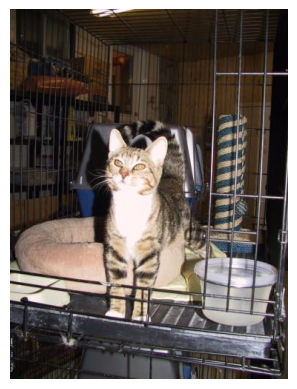

In [13]:
random_image_path = random.choice(all_image_paths)
print(f"Selected random image: {random_image_path}")

image = Image.open(random_image_path)
plt.imshow(image)
plt.axis('off')
plt.show()

## References

**Dataset source:** [Microsoft "Kaggle Cats and Dogs" Dataset](https://www.microsoft.com/en-us/download/details.aspx?id=54765)